# Visualizing Fine-Tuning Temporal Decay (T2D)

This notebook inspects temporal decay polynomials learned after T2D fine-tuning and compares them to pretraining. It supports both baseline TALE-EHR and age-conditioned TALE-EHR fine-tuned checkpoints using the same loading logic.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from model.tale_ehr import TALEEHR
from model.tale_ehr_age import TALEEHRAge

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})
AGE_PALETTE = sns.color_palette("viridis", n_colors=6)

FIGURES_DIR = REPO_ROOT / "figures" / "finetune_decay"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

IS_AGE_CONDITIONED = None  # set by Cell 2

print(f"Repo root: {REPO_ROOT}")
print(f"Figures dir: {FIGURES_DIR}")
print(f"Torch version: {torch.__version__}")

Repo root: /home/suraj/Git/Age-conditioned-pediatric-EHR
Figures dir: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/finetune_decay
Torch version: 2.8.0+rocm6.4


In [2]:
CHECKPOINT_PATH = "checkpoints/finetune/t2d_run_20260428_004847/best.pt"
EMBEDDING_PATH = "data/processed/bge_embeddings.pt"
VOCAB_PATH = "data/processed/code_vocab.json"
DEVICE = "cpu"

DEFAULTS = {
    "d_model": 256,
    "poly_degree": 5,
    "demo_hidden": 64,
    "age_emb_dim": 32,
    "age_hidden_dim": 64,
    "age_conditioning_mode": "real",
}


def load_checkpoint(path: Path):
    # weights_only=False is required for some checkpoints containing python objects.
    return torch.load(path, map_location="cpu", weights_only=False)


def infer_variant(ckpt, state_dict, config):
    v = ckpt.get("model_variant", None)
    if isinstance(v, str) and v.strip():
        low = v.lower()
        if "age" in low:
            return "age_conditioned"
        if "baseline" in low or "taleehr" in low:
            return "baseline"

    v2 = config.get("model_variant", None)
    if isinstance(v2, str) and v2.strip():
        low = v2.lower()
        if "age" in low:
            return "age_conditioned"
        if "baseline" in low or "taleehr" in low:
            return "baseline"

    key_join = "\n".join(state_dict.keys())
    if ("age_coeff_gen" in key_join) or ("age_emb" in key_join):
        return "age_conditioned"
    return "baseline"


def extract_encoder_state_dict(ckpt):
    if "encoder_state_dict" in ckpt:
        return ckpt["encoder_state_dict"], []

    if "model_state_dict" in ckpt:
        raw = ckpt["model_state_dict"]
        if any(k.startswith("backbone.") for k in raw):
            enc = {k[len("backbone."):]: v for k, v in raw.items() if k.startswith("backbone.")}
            dropped = [k for k in raw.keys() if not k.startswith("backbone.")]
            return enc, dropped
        return raw, []

    if "state_dict" in ckpt:
        raw = ckpt["state_dict"]
        return raw, []

    raise KeyError("No usable state dict key found (expected model_state_dict/encoder_state_dict/state_dict).")


def instantiate_model(variant, num_codes, embedding_path, resolved):
    if variant == "age_conditioned":
        return TALEEHRAge(
            embedding_path=embedding_path,
            num_codes=num_codes,
            d_model=resolved["d_model"],
            poly_degree=resolved["poly_degree"],
            demo_hidden=resolved["demo_hidden"],
            age_conditioning_mode=resolved["age_conditioning_mode"],
            age_emb_dim=resolved["age_emb_dim"],
            age_hidden_dim=resolved["age_hidden_dim"],
        )

    return TALEEHR(
        embedding_path=embedding_path,
        num_codes=num_codes,
        d_model=resolved["d_model"],
        poly_degree=resolved["poly_degree"],
        demo_hidden=resolved["demo_hidden"],
    )


ckpt_path = REPO_ROOT / CHECKPOINT_PATH
embedding_path = REPO_ROOT / EMBEDDING_PATH
vocab_path = REPO_ROOT / VOCAB_PATH
config_path = ckpt_path.parent / "config.json"

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab = json.load(f)
num_codes = len(vocab)

cfg = {}
if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)
else:
    print(f"INFO: no config.json found at {config_path}; using defaults + checkpoint metadata.")

ckpt = load_checkpoint(ckpt_path)
print("Checkpoint top-level keys:", sorted(ckpt.keys()))
encoder_state_dict, dropped_non_backbone = extract_encoder_state_dict(ckpt)
print("Encoder state_dict entries:", len(encoder_state_dict))
if dropped_non_backbone:
    print("Dropped non-backbone keys from model_state_dict:", dropped_non_backbone)

resolved = DEFAULTS.copy()
for key in ["d_model", "poly_degree", "demo_hidden", "age_emb_dim", "age_hidden_dim", "age_conditioning_mode"]:
    if key in cfg:
        resolved[key] = cfg[key]

# Optional overrides if checkpoint args has useful metadata.
args = ckpt.get("args", {})
if isinstance(args, dict):
    for key in ["d_model", "poly_degree", "demo_hidden", "age_emb_dim", "age_hidden_dim", "age_conditioning_mode"]:
        if key in args and args[key] is not None:
            resolved[key] = args[key]

resolved["d_model"] = int(resolved["d_model"])
resolved["poly_degree"] = int(resolved["poly_degree"])
resolved["demo_hidden"] = int(resolved["demo_hidden"])
resolved["age_emb_dim"] = int(resolved["age_emb_dim"])
resolved["age_hidden_dim"] = int(resolved["age_hidden_dim"])
resolved["age_conditioning_mode"] = str(resolved["age_conditioning_mode"])

variant = infer_variant(ckpt, encoder_state_dict, cfg)
IS_AGE_CONDITIONED = (variant == "age_conditioned")
model = instantiate_model(variant, num_codes, embedding_path, resolved)

load_result = model.load_state_dict(encoder_state_dict, strict=False)
model = model.to(DEVICE).double()
model.eval()

missing_keys = list(load_result.missing_keys)
unexpected_keys = list(load_result.unexpected_keys)
print("missing_keys:", missing_keys)
print("unexpected_keys:", unexpected_keys)

allowed_missing_prefixes = (
    "code_predictor.",
    "intensity_predictor.",
)
allowed_unexpected_prefixes = (
    "classifier.",
    "head.",
    "prediction_head.",
    "task_head.",
)

bad_missing = [k for k in missing_keys if not any(k.startswith(p) for p in allowed_missing_prefixes)]
bad_unexpected = [k for k in unexpected_keys if not any(k.startswith(p) for p in allowed_unexpected_prefixes)]

if bad_missing or bad_unexpected:
    print("WARNING: non-head missing/unexpected keys detected.")
    if bad_missing:
        print("  Non-head missing keys:", bad_missing)
    if bad_unexpected:
        print("  Non-head unexpected keys:", bad_unexpected)
else:
    print("State-dict load looks consistent with backbone/head separation.")

attn_coeff = model.time_aware_attention.temporal_weight.coefficients.detach().cpu()
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nLoaded fine-tuning checkpoint sanity info")
print("- checkpoint:", ckpt_path)
print("- epoch:", ckpt.get("epoch", "unknown"))
print("- variant:", variant)
print("- age_conditioning_mode:", resolved["age_conditioning_mode"] if IS_AGE_CONDITIONED else "n/a (baseline)")
print("- d_model:", resolved["d_model"], "poly_degree:", resolved["poly_degree"], "demo_hidden:", resolved["demo_hidden"])
print("- num_codes:", num_codes)
print("- total params:", total_params)
print("- trainable params:", trainable_params)
print("- attention base coefficients:", [round(float(x), 6) for x in attn_coeff])

if IS_AGE_CONDITIONED:
    last_w = model.time_aware_attention.temporal_weight.age_coeff_gen.mlp[-1].weight.detach()
    print("- age-MLP last-layer weight L2 norm:", float(last_w.norm().cpu()))

print("IS_AGE_CONDITIONED:", IS_AGE_CONDITIONED)

INFO: no config.json found at /home/suraj/Git/Age-conditioned-pediatric-EHR/checkpoints/finetune/t2d_run_20260428_004847/config.json; using defaults + checkpoint metadata.
Checkpoint top-level keys: ['args', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss', 'val_metrics']
Encoder state_dict entries: 12
Dropped non-backbone keys from model_state_dict: ['classifier.weight', 'classifier.bias']


missing_keys: ['code_predictor.0.weight', 'code_predictor.0.bias', 'code_predictor.2.weight', 'code_predictor.2.bias', 'code_predictor.4.weight', 'code_predictor.4.bias', 'intensity_predictor.0.weight', 'intensity_predictor.0.bias', 'intensity_predictor.2.weight', 'intensity_predictor.2.bias', 'intensity_predictor.4.weight', 'intensity_predictor.4.bias', 'intensity_predictor.6.weight', 'intensity_predictor.6.bias']
unexpected_keys: []
State-dict load looks consistent with backbone/head separation.

Loaded fine-tuning checkpoint sanity info
- checkpoint: /home/suraj/Git/Age-conditioned-pediatric-EHR/checkpoints/finetune/t2d_run_20260428_004847/best.pt
- epoch: 5
- variant: baseline
- age_conditioning_mode: n/a (baseline)
- d_model: 256 poly_degree: 5 demo_hidden: 64
- num_codes: 30635
- total params: 11053048
- trainable params: 11053048
- attention base coefficients: [0.102122, 0.281671, 0.10224, 0.000701, -0.019555, 0.002719]
IS_AGE_CONDITIONED: False


In [3]:
def _require_age_conditioned(model):
    has_age = hasattr(model.time_aware_attention, "age_emb") and hasattr(model.time_aware_attention.temporal_weight, "age_coeff_gen")
    if not has_age:
        raise RuntimeError("This helper requires an age-conditioned TALE-EHR model.")


def get_age_features(model, ages_years):
    """Run the Fourier embedding on a 1D tensor of ages in years.
    Returns shape [N, 32]."""
    _require_age_conditioned(model)
    ages = torch.as_tensor(ages_years, dtype=torch.float64, device=next(model.parameters()).device)
    if ages.ndim != 1:
        raise ValueError(f"ages_years must be 1D, got shape {tuple(ages.shape)}")
    with torch.no_grad():
        feats = model.time_aware_attention.age_emb(ages)
    return feats


def get_delta_alpha(model, ages_years):
    """Compute Delta_alpha for each age. Returns shape [N, 6] for poly_degree=5."""
    _require_age_conditioned(model)
    age_features = get_age_features(model, ages_years)
    with torch.no_grad():
        delta_alpha = model.time_aware_attention.temporal_weight.age_coeff_gen(age_features)
    return delta_alpha


def get_full_alpha(model, ages_years):
    """Compute alpha_k(a) = base_k + Delta_alpha_k(a). Returns shape [N, 6]."""
    _require_age_conditioned(model)
    delta_alpha = get_delta_alpha(model, ages_years)
    base = model.time_aware_attention.temporal_weight.coefficients.view(1, -1)
    return base + delta_alpha


def compute_w_curve(model, ages_years, delta_t_grid):
    """For each (age, delta_t) pair, compute temporal weight w.
    ages_years: [N_ages] in years.
    delta_t_grid: [N_dt] in log1p(weeks) units.
    Returns shape [N_ages, N_dt]."""
    _require_age_conditioned(model)
    ages = torch.as_tensor(ages_years, dtype=torch.float64, device=next(model.parameters()).device)
    dt = torch.as_tensor(delta_t_grid, dtype=torch.float64, device=next(model.parameters()).device)
    if ages.ndim != 1:
        raise ValueError(f"ages_years must be 1D, got shape {tuple(ages.shape)}")
    if dt.ndim != 1:
        raise ValueError(f"delta_t_grid must be 1D, got shape {tuple(dt.shape)}")

    age_features = get_age_features(model, ages).unsqueeze(1)
    dt_tensor = dt.view(1, 1, -1).expand(ages.shape[0], 1, dt.shape[0])

    with torch.no_grad():
        w = model.time_aware_attention.temporal_weight(dt_tensor, age_features)
    return w.squeeze(1)


def compute_w_curve_aggregation(model, delta_t_grid):
    """Compute w(Δt) for MultiScaleTemporalAggregation's polynomial.
    Returns shape [N_dt]. No age conditioning in aggregation."""
    dt = torch.as_tensor(delta_t_grid, dtype=torch.float64, device=next(model.parameters()).device)
    if dt.ndim != 1:
        raise ValueError(f"delta_t_grid must be 1D, got shape {tuple(dt.shape)}")
    with torch.no_grad():
        w = model.temporal_aggregation.temporal_weight(dt)
    return w


print("Helper functions ready.")

Helper functions ready.


## Figure 1 — Attention-module decay function

Headline plot: temporal weight from the attention module after fine-tuning. For age-conditioned models this is the base polynomial before age modulation.


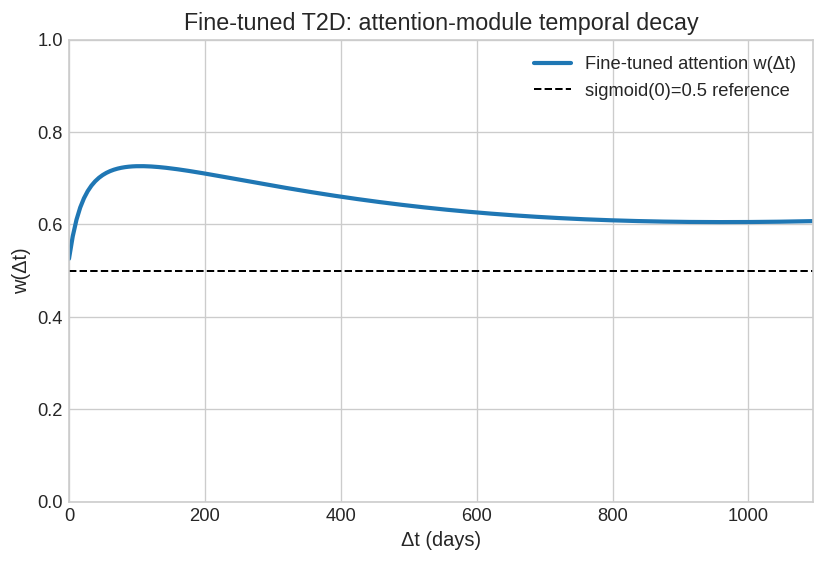

Attention coefficients (fine-tuned): [0.102122, 0.281671, 0.10224, 0.000701, -0.019555, 0.002719]
Saved: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/finetune_decay/attention_decay.png
Saved: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/finetune_decay/attention_decay.pdf


In [4]:
days_grid = np.linspace(0.0, 1095.0, 200)
log_dt_grid = np.log1p(days_grid / 7.0)

finetune_attn_coeff = model.time_aware_attention.temporal_weight.coefficients.detach().cpu().numpy().astype(np.float64)
poly = np.zeros_like(log_dt_grid)
for k, c in enumerate(finetune_attn_coeff):
    poly += c * (log_dt_grid ** k)
finetune_attn_w = 1.0 / (1.0 + np.exp(-poly))

fig, ax = plt.subplots()
ax.plot(days_grid, finetune_attn_w, color="tab:blue", lw=2.5, label="Fine-tuned attention w(Δt)")
ax.axhline(0.5, color="black", linestyle="--", lw=1.2, label="sigmoid(0)=0.5 reference")
ax.set_xlim(0, 1095)
ax.set_ylim(0, 1)
ax.set_xlabel("Δt (days)")
ax.set_ylabel("w(Δt)")
ax.set_title("Fine-tuned T2D: attention-module temporal decay")
ax.legend(loc="best")

png_path = FIGURES_DIR / "attention_decay.png"
pdf_path = FIGURES_DIR / "attention_decay.pdf"
fig.savefig(png_path, bbox_inches="tight", dpi=300)
fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
plt.show()

print("Attention coefficients (fine-tuned):", [round(float(x), 6) for x in finetune_attn_coeff])
print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")

Interpretation prompt:

- Does this curve show a **decreasing** shape with $\Delta t$ (proper decay), a **flat** shape, or a **rising** shape (inverted, like pretrained checkpoints)?
- Inspect the printed coefficients; negative terms are often necessary to produce net downward behavior over $\Delta t>0$.

## Figure 2 — Aggregation-module decay function

The aggregation module has a separate polynomial temporal weight; plot it for completeness.


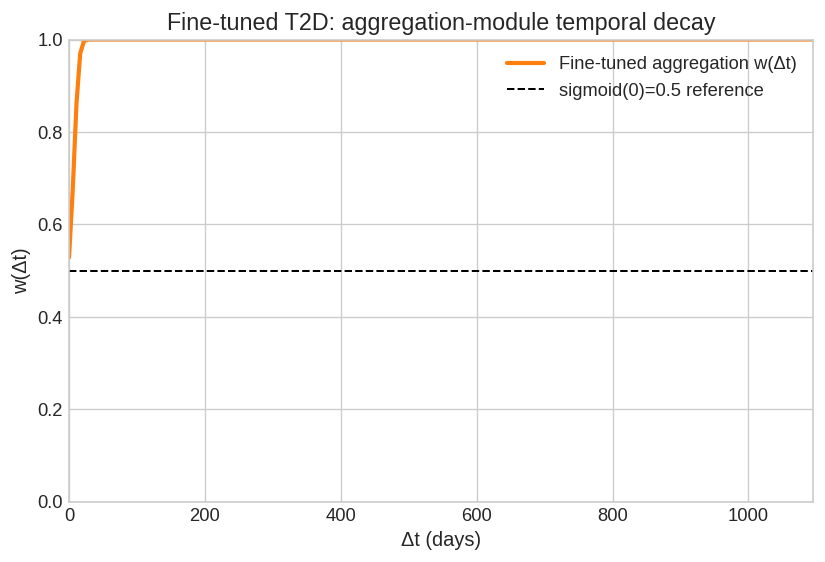

Aggregation coefficients (fine-tuned): [0.112043, 0.570331, 0.476257, 0.379742, 0.305888, 0.246798]
Saved: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/finetune_decay/aggregation_decay.png
Saved: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/finetune_decay/aggregation_decay.pdf


In [5]:
days_grid = np.linspace(0.0, 1095.0, 200)
log_dt_grid = np.log1p(days_grid / 7.0)

finetune_agg_coeff = model.temporal_aggregation.temporal_weight.coefficients.detach().cpu().numpy().astype(np.float64)
finetune_agg_w = compute_w_curve_aggregation(model, log_dt_grid).detach().cpu().numpy().astype(np.float64)

fig, ax = plt.subplots()
ax.plot(days_grid, finetune_agg_w, color="tab:orange", lw=2.5, label="Fine-tuned aggregation w(Δt)")
ax.axhline(0.5, color="black", linestyle="--", lw=1.2, label="sigmoid(0)=0.5 reference")
ax.set_xlim(0, 1095)
ax.set_ylim(0, 1)
ax.set_xlabel("Δt (days)")
ax.set_ylabel("w(Δt)")
ax.set_title("Fine-tuned T2D: aggregation-module temporal decay")
ax.legend(loc="best")

png_path = FIGURES_DIR / "aggregation_decay.png"
pdf_path = FIGURES_DIR / "aggregation_decay.pdf"
fig.savefig(png_path, bbox_inches="tight", dpi=300)
fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
plt.show()

print("Aggregation coefficients (fine-tuned):", [round(float(x), 6) for x in finetune_agg_coeff])
print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")

## Figure 3 — Side-by-side: pretrained vs fine-tuned attention decay

This directly tests whether fine-tuning reshaped the temporal decay versus pretraining.


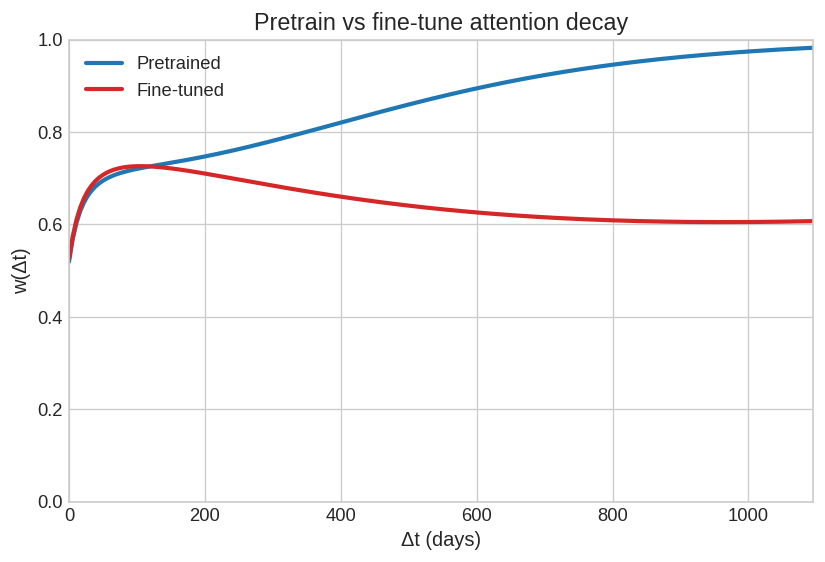

Pretrained attention coefficients: [0.076193, 0.288176, 0.099352, -0.004546, -0.023063, 0.004715]
Fine-tuned attention coefficients: [0.102122, 0.281671, 0.10224, 0.000701, -0.019555, 0.002719]
Saved: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/finetune_decay/pretrain_vs_finetune.png
Saved: /home/suraj/Git/Age-conditioned-pediatric-EHR/figures/finetune_decay/pretrain_vs_finetune.pdf


In [6]:
PRETRAIN_CHECKPOINT = "checkpoints/run_20260427_152603/best_pretrain.pt"  # baseline pretraining
# For age-conditioned fine-tuned checkpoints, switch this to an age-conditioned pretrain checkpoint.

if IS_AGE_CONDITIONED:
    print("GUIDANCE: set PRETRAIN_CHECKPOINT to the matching age-conditioned pretraining run for a fair comparison.")

pretrain_ckpt_path = REPO_ROOT / PRETRAIN_CHECKPOINT
pre_ckpt = load_checkpoint(pretrain_ckpt_path)
pre_cfg = {}
pre_cfg_path = pretrain_ckpt_path.parent / "config.json"
if pre_cfg_path.exists():
    with open(pre_cfg_path, "r", encoding="utf-8") as f:
        pre_cfg = json.load(f)

pre_sd, pre_dropped = extract_encoder_state_dict(pre_ckpt)
pre_variant = infer_variant(pre_ckpt, pre_sd, pre_cfg)

pre_resolved = DEFAULTS.copy()
for key in ["d_model", "poly_degree", "demo_hidden", "age_emb_dim", "age_hidden_dim", "age_conditioning_mode"]:
    if key in pre_cfg:
        pre_resolved[key] = pre_cfg[key]

pre_resolved["d_model"] = int(pre_resolved["d_model"])
pre_resolved["poly_degree"] = int(pre_resolved["poly_degree"])
pre_resolved["demo_hidden"] = int(pre_resolved["demo_hidden"])
pre_resolved["age_emb_dim"] = int(pre_resolved["age_emb_dim"])
pre_resolved["age_hidden_dim"] = int(pre_resolved["age_hidden_dim"])
pre_resolved["age_conditioning_mode"] = str(pre_resolved["age_conditioning_mode"])

if pre_variant != ("age_conditioned" if IS_AGE_CONDITIONED else "baseline"):
    print(f"WARNING: variant mismatch. Fine-tuned variant={'age_conditioned' if IS_AGE_CONDITIONED else 'baseline'}, pretrain variant={pre_variant}")

pre_model = instantiate_model(pre_variant, num_codes, embedding_path, pre_resolved)
pre_model.load_state_dict(pre_sd, strict=True)
pre_model = pre_model.to(DEVICE).double()
pre_model.eval()

days_grid = np.linspace(0.0, 1095.0, 200)
log_dt_grid = np.log1p(days_grid / 7.0)

pretrained_attn_coeff = pre_model.time_aware_attention.temporal_weight.coefficients.detach().cpu().numpy().astype(np.float64)
pre_poly = np.zeros_like(log_dt_grid)
for k, c in enumerate(pretrained_attn_coeff):
    pre_poly += c * (log_dt_grid ** k)
pretrained_attn_w = 1.0 / (1.0 + np.exp(-pre_poly))

fin_poly = np.zeros_like(log_dt_grid)
for k, c in enumerate(finetune_attn_coeff):
    fin_poly += c * (log_dt_grid ** k)
finetuned_attn_w = 1.0 / (1.0 + np.exp(-fin_poly))

fig, ax = plt.subplots()
ax.plot(days_grid, pretrained_attn_w, color="tab:blue", lw=2.5, label="Pretrained")
ax.plot(days_grid, finetuned_attn_w, color="tab:red", lw=2.5, label="Fine-tuned")
ax.set_xlim(0, 1095)
ax.set_ylim(0, 1)
ax.set_xlabel("Δt (days)")
ax.set_ylabel("w(Δt)")
ax.set_title("Pretrain vs fine-tune attention decay")
ax.legend(loc="best")

png_path = FIGURES_DIR / "pretrain_vs_finetune.png"
pdf_path = FIGURES_DIR / "pretrain_vs_finetune.pdf"
fig.savefig(png_path, bbox_inches="tight", dpi=300)
fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
plt.show()

print("Pretrained attention coefficients:", [round(float(x), 6) for x in pretrained_attn_coeff])
print("Fine-tuned attention coefficients:", [round(float(x), 6) for x in finetune_attn_coeff])
print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")

Interpretation:

- If fine-tuning yields a proper decreasing curve while pretraining was rising, fine-tuning likely creates the decay structure (consistent with TALE-EHR Figure 2 using fine-tuned models).
- If both curves remain similar and rising, fine-tuning did not resolve the decay-shape issue and the polynomial-sigmoid setup may need redesign.


## Figure 4 — Age-stratified fine-tuned decay curves (age-conditioned only)


In [7]:
if IS_AGE_CONDITIONED:
    ages_to_plot = np.array([0.5, 2, 5, 12, 25, 50, 75, 90], dtype=np.float64)
    days_grid = np.linspace(0.0, 1095.0, 200)
    log_dt_grid = np.log1p(days_grid / 7.0)

    w_curves = compute_w_curve(model, ages_to_plot, log_dt_grid).detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(9, 5.5))
    curve_colors = sns.color_palette("viridis", n_colors=len(ages_to_plot))
    for age, curve, color in zip(ages_to_plot, w_curves, curve_colors):
        is_extrap = age < 18.0
        label = f"age={age:g}y" + (" (extrapolated)" if is_extrap else "")
        ls = "--" if is_extrap else "-"
        ax.plot(days_grid, curve, color=color, lw=2.2, linestyle=ls, label=label)

    ax.set_xlim(0, 1095)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Δt (days)")
    ax.set_ylabel("w(Δt, a)")
    ax.set_title("Age-conditioned temporal decay w(Δt, a) — fine-tuned")
    ax.legend(loc="upper right", frameon=True)

    png_path = FIGURES_DIR / "age_decay_curves_finetuned.png"
    pdf_path = FIGURES_DIR / "age_decay_curves_finetuned.pdf"
    fig.savefig(png_path, bbox_inches="tight", dpi=300)
    fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
    plt.show()

    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")
else:
    display(Markdown("Baseline variant detected: age-stratified decay curves are not applicable and are skipped."))

Baseline variant detected: age-stratified decay curves are not applicable and are skipped.

## Numerical summary

Compact table of coefficients and key sigmoid values before vs after fine-tuning.


In [8]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

probe_days = np.array([0.0, 100.0, 500.0, 1000.0], dtype=np.float64)
probe_dt = np.log1p(probe_days / 7.0)

pre_probe_poly = np.zeros_like(probe_dt)
fin_probe_poly = np.zeros_like(probe_dt)
for k in range(len(pretrained_attn_coeff)):
    pre_probe_poly += pretrained_attn_coeff[k] * (probe_dt ** k)
for k in range(len(finetune_attn_coeff)):
    fin_probe_poly += finetune_attn_coeff[k] * (probe_dt ** k)

pre_probe_w = sigmoid(pre_probe_poly)
fin_probe_w = sigmoid(fin_probe_poly)

rows = []
rows.append("| Metric | Value |")
rows.append("|---|---:|")
rows.append(f"| Fine-tuned attention coefficients | `{[round(float(x), 6) for x in finetune_attn_coeff]}` |")
rows.append(f"| Fine-tuned aggregation coefficients | `{[round(float(x), 6) for x in finetune_agg_coeff]}` |")
rows.append(f"| Pretrained attention coefficients | `{[round(float(x), 6) for x in pretrained_attn_coeff]}` |")

for d, p, f in zip(probe_days, pre_probe_w, fin_probe_w):
    rows.append(f"| Sigmoid w at Δt={int(d)} days (pretrained) | {float(p):.6f} |")
    rows.append(f"| Sigmoid w at Δt={int(d)} days (fine-tuned) | {float(f):.6f} |")

if IS_AGE_CONDITIONED:
    canonical_ages = np.array([0.5, 5, 12, 25, 50, 75, 90], dtype=np.float64)
    canon_delta = get_delta_alpha(model, canonical_ages).detach().cpu().numpy()
    canon_norms = np.linalg.norm(canon_delta, axis=1)
    for age, nrm in zip(canonical_ages, canon_norms):
        rows.append(f"| ||Δα||₂ at age {age:g} | {float(nrm):.6f} |")

display(Markdown("\n".join(rows)))
print("Summary table rendered.")

| Metric | Value |
|---|---:|
| Fine-tuned attention coefficients | `[0.102122, 0.281671, 0.10224, 0.000701, -0.019555, 0.002719]` |
| Fine-tuned aggregation coefficients | `[0.112043, 0.570331, 0.476257, 0.379742, 0.305888, 0.246798]` |
| Pretrained attention coefficients | `[0.076193, 0.288176, 0.099352, -0.004546, -0.023063, 0.004715]` |
| Sigmoid w at Δt=0 days (pretrained) | 0.519039 |
| Sigmoid w at Δt=0 days (fine-tuned) | 0.525508 |
| Sigmoid w at Δt=100 days (pretrained) | 0.719967 |
| Sigmoid w at Δt=100 days (fine-tuned) | 0.725778 |
| Sigmoid w at Δt=500 days (pretrained) | 0.859321 |
| Sigmoid w at Δt=500 days (fine-tuned) | 0.640389 |
| Sigmoid w at Δt=1000 days (pretrained) | 0.974052 |
| Sigmoid w at Δt=1000 days (fine-tuned) | 0.604940 |

Summary table rendered.


## Diagnostic — did fine-tuning update temporal polynomial coefficients?

Compute $\|lpha_{fine}-lpha_{pre}\|_2$ on attention coefficients.


In [9]:
delta = float(np.linalg.norm(finetune_attn_coeff - pretrained_attn_coeff, ord=2))
print(f"L2 delta between fine-tuned and pretrained attention coefficients: {delta:.6f}")
if delta > 0.1:
    print("Interpretation: fine-tuning materially updated the temporal polynomial.")
elif delta < 0.001:
    print("Interpretation: polynomial coefficients were effectively frozen during fine-tuning.")
else:
    print("Interpretation: fine-tuning changed the polynomial modestly.")

L2 delta between fine-tuned and pretrained attention coefficients: 0.027691
Interpretation: fine-tuning changed the polynomial modestly.
